# MOD510: Project 4

**Deadline: 01. December 2025 (23:59)**


**Group members**

* Simen Sæverud Gåsland

* Nataliia Aksamentova

# Abstract 
**Write here**

# Introduction
**Write here**

# Exercise 1: Stochastic modeling of mixing tanks


## Part 1: Single Mixing Tank with Parameter Uncertainty 

### Task 1 - Derivation of the concentration in a single mixing tank

We concider a well-mixed tank with constant volume $V$, inflow rate $Q_{in}$, outflow rate $Q_{out}$ and constant inflow concentration $C_{in}$.

To determine the solute concentration in the tank, $C(t)$, the following governing differential equation must be solved: 


$$\frac{dC}{dt} = \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C.$$

The governing differential equation is a first-order linear ordinary differential equation of the form

$$\frac{dC}{dt} + P(t)C = Q(t),$$

with

$$P(t) = \frac{Q_{out}}{V}, \quad  \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

where $P$ and $Q$ are constants, since the system parameters do not vary with time.

**Integrating factor**

The integrating factor of a first-order linear ODE is defined as

$$I(t) = e^{\int P(t) \text{ dt}}.$$

For readability, we will write the exponential function using the notation $\exp(\space)$:

$$I(t) = \exp\left(\int P(t) \text{ dt}\right).$$

Substituting $P(t) = \frac{Q_{out}}{V}$, we obtain

$$I(t) = \exp\left(\int \frac{Q_{out}}{V} \text{ dt}\right) \quad \Rightarrow \quad I(t) = \exp\left(\frac{Q_{out}}{V}t\right)$$

Using the integrating factor $I(t)$, the solution of the first-order linear ODE can be written as

$$C(t) = \frac{1}{I(t)}\left( \int I(t) Q(t) \text{ dt} + K\right),$$

where $K$ is an integration constant. 

Substituting 

$$I(t) = \exp\left(\frac{Q_{out}}{V}t\right), \quad \quad \quad Q(t) = \frac{Q_{in}}{V} C_{in},$$

gives

$$C(t) = \frac{1}{\exp\left(\frac{Q_{out}}{V}t\right)} \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right).$$

This can be rewritten as

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left( \int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} + K\right)$$

Evaluating the integral yields:

$$\int \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} \text{ dt} = \frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K$$

Substituting back, we obtain

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\frac{V}{Q_{out}} \exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{V} C_{in} + K \right)$$

This simplifies to

$$C(t) = \exp\left(-\frac{Q_{out}}{V}t\right) \cdot \left(\exp\left(\frac{Q_{out}}{V}t\right) \cdot \frac{Q_{in}}{Q_{out}} C_{in} + K \right)$$

Multiplying through gives

$$C(t) = K\exp\left(-\frac{Q_{out}}{V}t\right) + \frac{Q_{in}}{Q_{out}} C_{in}$$

Finally, the solution is

$$\boxed{C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in} }$$

### Task 2 - Analytical solution with average parameters

Using the average parameter values

$$V = 1000 \text{ L} \quad Q_{out} = 100 \text{ L/s} \quad Q_{in} = 100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C(0) = 3.5 \text{ g/L},$$

the general solution from Task $1$, 

$$C(t) = K e^{- \frac{Q_{out}}{V}t} + \frac{Q_{in}}{Q_{out}}C_{in}$$

becomes

$$ C(t) =  K e^{- \frac{100 \text{ L/s}}{1000 \text{ L}} t} + \frac{100 \text{ L/s}}{100 \text{ L/s}} \cdot 0.25 \text{ g/L}. $$

Which simplifies to 

$$C(t) = K e^{-0.1 \text{ s}^{-1}t} + 0.25 \text{ g/L}$$

To find $K$, we apply the initial condition $C(0) = 3.5$ g/L:

$$K e^{0} + 0.25 \text{ g/L} = 3.5 \text{ g/L} \quad \Rightarrow \quad K = 3.5\text{ g/L} - 0.25 \text{ g/L} \quad \Rightarrow \quad K = 3.25\text{ g/L}$$

With $t$ measured in seconds, the concentration $C(t)$ in g/L is therefore

$$\boxed{C(t)= 3.25 \cdot e^{-0.1t} + 0.25}$$

The concentration decreases exponentially from the initial value $3.5$ g/L towards the steady-state value $0.25$ g/L. 

### Task 3 - Probabilistic interpretation of outflow

The probabilitiy that a gram of solute leaves the tank during a time interval $\Delta t$ is 

$$p = 1 - e^{-\frac{Q_{out}}{V} \Delta t}.$$

**Interpretation:**
\begin{align*}
1 - p = & \text{ probability that a gram of solute remains in the tank.}\\
p = & \text{ probability that a gram of solute leaves the tank.} 
\end{align*}


This gives the following update for the concentration:

$$\boxed{C(t + \Delta t) = (1 - p)C(t) + pC_{in}}$$

**Broken down:**
\begin{align*}
(1 - p)C(t) = & \text{ portion of the old concentration that remains in the tank.}\\
pC_{in} = & \text{ portion that is replaced by fresh inflow.} 
\end{align*}

This shows that the updated concentration depends on how much of the old solution remains and how much fresh solution enters, controlled by the probabillity of solute leaving during the time interval. 

### Task 4 - Monte Carlo Simulation with Fixed Parameters (Option 1)

To make the simulation structured and reusable, the Monte Carlo procedure is implemented as a generalized function. This function allows switching between fixed parameters per run and parameters that vary at each time step through a Boolean input `fixed_parameters`, making it straightforward to compare the two modelling approaches examined in Task $4$ and $5$. 

To further avoid code duplication, the function includes an `n_tanks` parameter, allowing the same simulation structure to be reused for the multi-tank system introduced in Parts $2$ and $3$. Additionally, the parameter `c_in` is added to support later validation against deterministic ODE solutions, where a non-zero inflow concentration is required.

For Option $1$, all uncertain parameters are sampled once at the beginning of each Monte Carlo run and remain constant throughout the simulation. The parameters follow the uniform distributions: 

* $V \sim \text{Uniform}(950, 1050)$ L
* $Q_{out} = Q_{in} \sim \text{Uniform}(95, 105)$ L/s
* $C_{in} = 0$ g/L
* $C(0) \sim \text{Uniform}(3.4, 3.6)$ g/L

The solute concentration is updated stochastically at each time step using the probabilistic formulation from Task $3$.

A total of $100$ independent simulation runs are performed, each consisting of $1000$ time steps. These results are used to determine the mean concentration, standard deviation, and $95\%$ confidence intervals as functions of time, where the confidence intervals are constructed using the $2.5 \text{th}$ and $97.5 \text{th}$ percentiles of the simulated concentration values.

In [1]:
import numpy as np
from numpy import random as rnd

#For reproducibility
rnd.seed(18)

def monte_carlo_simulation(t0, tf, n_runs, n_steps, fixed_parameters = True, n_tanks = 1, c_in = 0.0):
    '''
    Monte Carlo simulation of solute concentration evolution in mixing tanks.

    Input
    ------
    t0: float
        Start time [s].
    tf: float
        Final time [s].
    n_runs: int
        Number of Monte Carlo runs.
    n_steps: int
        Number of time steps per run.
    fixed_parameters: bool
        If True, parameters are fixed per run.
        If False, parameters vary at each time step.
    n_tanks: int
        Number of tanks.
    c_in: float
        Solute concentration of the inflow.

    Output
    ------
    c_mean: ndarray (shape = (n_tanks, n_steps)
        Mean concentration over runs.
    c_std: ndarray (shape = (n_tanks, n_steps)
        Standard deviation over runs.
    ci_lower: ndarray (shape = (n_tanks, n_steps)
        Lower bound of the 95% confidence interval (2.5th percentile).
    ci_upper: ndarray (shape = (n_tanks, n_steps)
        Upper bound of the 95% confidence interval (97.5th percentile).
    '''
    #Delta time
    dt = (tf - t0) / n_steps

    #Allocate concentration history
    concentration = np.zeros((n_tanks, n_runs, n_steps))

    #Monte Carlo simulation
    for run in range(n_runs):
        v = rnd.uniform(950, 1050)
        c = np.zeros(n_tanks)

        #Initial concentration
        c[0] = rnd.uniform(3.4, 3.6)
        c[1:] = rnd.uniform(0, 0.1, size = n_tanks - 1)

        if fixed_parameters:
            q_out = q_in = rnd.uniform(95, 105)

        for t in range(n_steps):
            if not fixed_parameters:
                q_out = q_in = rnd.uniform(95, 105)

            p = 1 - np.exp((-q_out / v) * dt)

            #Update tanks
            for n in range(n_tanks):
                inflow = c_in if n == 0 else c[n-1]
                c[n] = c[n] * (1 - p) + inflow * p

            concentration[:, run, t] = c

    #Mean concentration across runs
    c_mean = np.mean(concentration, axis = 1)

    #Standard deviation
    c_std = np.std(concentration, axis = 1)

    #95% confidence intervals
    #ci_lower = c_mean - 1.960 * (c_std / np.sqrt(n_runs))
    #ci_upper = c_mean + 1.960 * (c_std / np.sqrt(n_runs))
    ci_lower, ci_upper = np.percentile(concentration, [2.5, 97.5], axis = 1)

    return c_mean, c_std, ci_lower, ci_upper

After defining the Monte Carlo function, the simulation settings for Task $4$ are specified. While the number of time steps is explicitly defined as $1000$ in the project description, the total simulation time is not specified. A simulation duration of $100$ seconds is therefore selected. This is discretised into $1000$ time steps, resulting in a time step size of 

$$\Delta t = \frac{t_f - t_0}{n_{\text{steps}}} = \frac{100\text{ s} - 0 \text{ s}}{1000} = 0.1 \text{ s.}$$

Using these settings, the Monte Carlo simulation is then executed for Option $1$.

In [2]:
#Simulation settings (100s simulated with 1000 timesteps)
n_particles = 100
n_steps = 1000
t_start = 0
t_final = 100

#For task 4: Fixed parameter per run
fixed_parameters = True

#Perform Monte Carlo simulation
(c_mean_op1,
 c_std_op1,
 ci_lower_op1,
 ci_upper_op1
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

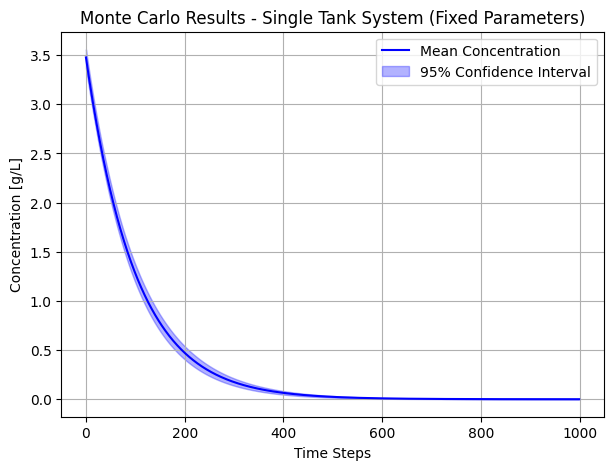

In [3]:
import matplotlib.pyplot as plt

#Plotting the result
time_steps = np.arange(n_steps)
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha = 0.3, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Single Tank System (Fixed Parameters)')
plt.grid()
plt.show()

The concentration decays exponentially towards zero, which is consistent with the absence of inflow to the tank. The uncertainty is relatively low at early times, increases towards the transition region (the "elbow" of the curve), and gradually decreases as the concentration approaches zero. A detailed comparison of both options is provided in Task $5$.

### Task 5 - Monte Carlo Simulation with Time-Varying Parameters (Option 2)

In Option $2$, the same Monte Carlo framework is used, but the flow rates are now allowed to fluctuate at each time step. The tank volume $V$ and initial concentration $C(0)$ are still sampled once per run and kept fixed throughout that run, whereas the inflow and outflow rates are resampled at every time step. The inflow concentration remains zero. More precisely, the parameters are treated as follows: 

Sampled once per run: 
* $V \sim \text{Uniform}(950, 1050)$ L
* $C(0) \sim \text{Uniform}(3.4, 3.6)$ g/L

Resampled at each time step
* $Q_{out} = Q_{in} \sim \text{Uniform}(95, 105)$ L/s
* $C_{in} = 0$ g/L (constant)


The configuration is implemented by calling the same `monte_carlo_simulation` function with the `fixed_parameters` variable set to `False`. 

In [4]:
#For task 5: parameters vary at each time step
fixed_parameters = False

#Perform Monte Carlo simulation with same settings as Task 4
(c_mean_op2,
 c_std_op2,
 ci_lower_op2,
 ci_upper_op2
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, fixed_parameters)

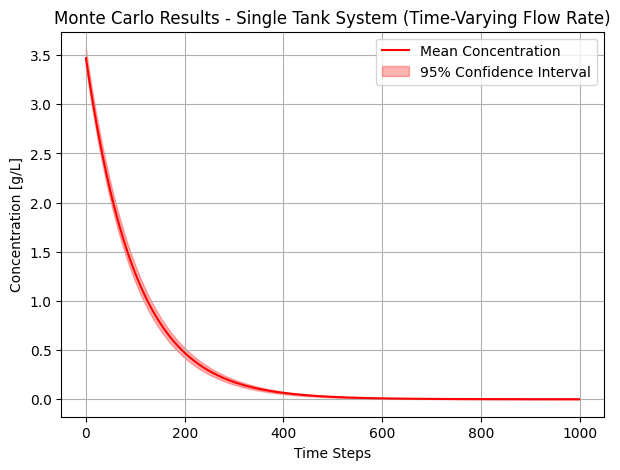

In [5]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha = 0.3, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Results - Single Tank System (Time-Varying Flow Rate)')
plt.grid()
plt.show()

The concentration decays exponentially towards zero, with a visibly narrower confidence interval compared to Option $1$. This indicates that time-varying flow rates reduce the uncertainty in the concentration evolution. A systematic comparison between the two modelling approaches is presented in the following section.

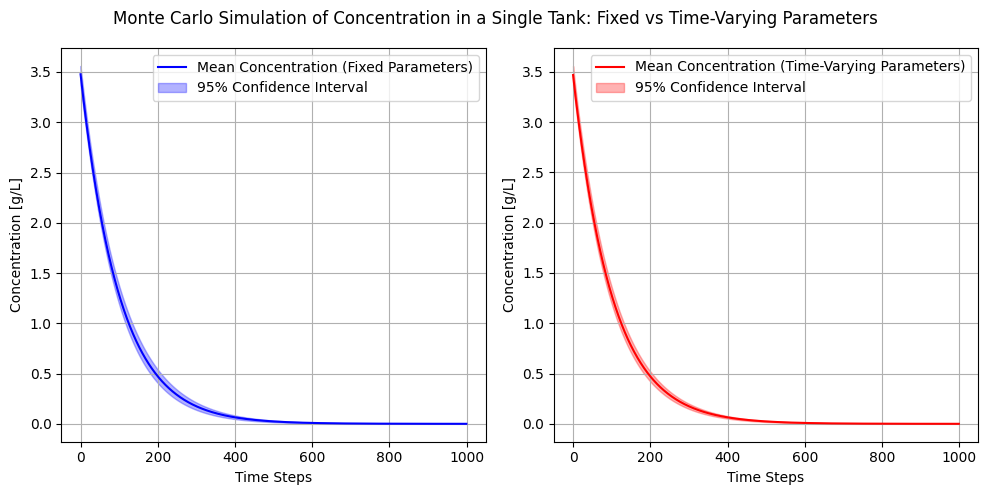

In [6]:
import matplotlib.pyplot as plt

time_steps = np.arange(n_steps)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(time_steps, c_mean_op1[0], color = 'blue',label = 'Mean Concentration (Fixed Parameters)')
plt.fill_between(time_steps, ci_lower_op1[0], ci_upper_op1[0], alpha = 0.3, color = 'blue', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.subplot(1, 2, 2)
plt.plot(time_steps, c_mean_op2[0], color = 'red', label = 'Mean Concentration (Time-Varying Parameters)')
plt.fill_between(time_steps, ci_lower_op2[0], ci_upper_op2[0], alpha = 0.3, color = 'red', label = "95% Confidence Interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.suptitle('Monte Carlo Simulation of Concentration in a Single Tank: Fixed vs Time-Varying Parameters')
plt.tight_layout()
plt.show()


Both approaches show similar exponential decay behavior, but the fixed-parameter case exhibits a wider confidence interval than the time-varying case. This shows that when parameters are kept constant within each run, differences between runs persist over time, causing the simulation results to diverge more strongly and leading to greater variability.

Since the number of Monte Carlo runs is identical for both options, this difference cannot be attributed to sample size but rather sampling strategy. As mentioned in Gezerlis's book, Monte Carlo theory shows that such strategies can significantly affect estimator variance and uncertainty [\[$1$\]](#bib). 

To further quantify the difference in uncertainty, the width of the $95\%$ confidence interval is computed at each time step for both options. The mean interval width is then calculated as an overall measure of uncertainty, and the ratio between the two cases provides a direct comparison. The time evolution of the confidence interval width is also plotted to illusrate how to uncertainty develops throughout the simulation. 

In [7]:
width_op1 = ci_upper_op1[0] - ci_lower_op1[0]
width_op2 = ci_upper_op2[0] - ci_lower_op2[0]

mean_width_op1 = np.mean(width_op1)
mean_width_op2 = np.mean(width_op2)

print(f'Mean width option 1: {mean_width_op1:.4f} g/L')
print(f'Mean width option 2: {mean_width_op2:.4f} g/L')
print(f'Fixed parameters are {mean_width_op1/ mean_width_op2:.4f} times more uncertain')

Mean width option 1: 0.0549 g/L
Mean width option 2: 0.0459 g/L
Fixed parameters are 1.1975 times more uncertain


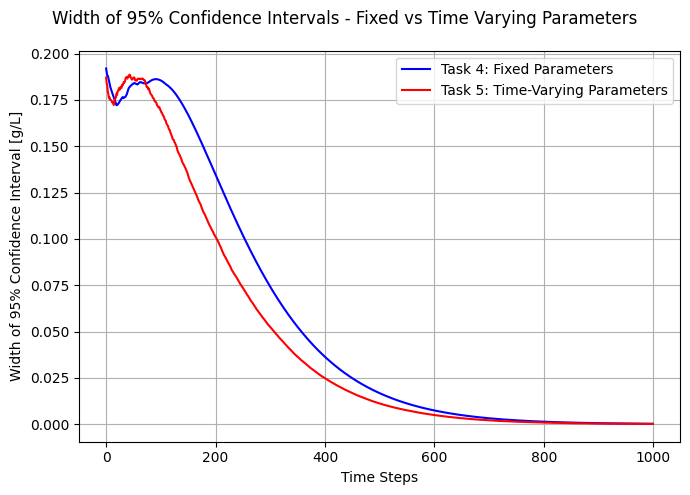

In [8]:
plt.figure(figsize=(7, 5))

plt.plot(time_steps, width_op1, color = 'blue',label = 'Task 4: Fixed Parameters')
plt.plot(time_steps, width_op2, color = 'red', label = 'Task 5: Time-Varying Parameters')
plt.legend()
plt.ylabel('Width of 95% Confidence Interval [g/L]')
plt.xlabel('Time Steps')
plt.grid()


plt.suptitle('Width of 95% Confidence Intervals - Fixed vs Time Varying Parameters')
plt.tight_layout()
plt.show()

The plot shows that the fixed-parameter case consistently has a wider confidence interval than the time-varying case. The mean widths of $0.0549$ g/L (Option 1) and $0.0459$ g/L (Option 2) indicate that the fixed-parameter model is about $1.20$ times more uncertain. This confirms that allowing the parameters to vary in time reduces the overall uncertainty in the concentration. 

## Part 2: Three Interconnected Tanks with Parameter Uncertainty

### Task 1 - Formulation of the Three-Tank System

The single-tank model from Part $1$ is now extended to a series of three mixed tanks with identical volume $V$. Tank $1$ receives an inflow with volumetric flow rate $Q_{in}$ and solute concentration $C_{in}$, while Tanks $2$ and $3$ receive their inflow from the preceding tank. Each tank discharges with flow rate $Q_{out}$. 

Let $C_1(t)$, $C_2(t)$, and $C_3(t)$ denote the solute concentration in Tanks $1$-$3$ respectively. The governing equations for the system are given by
\begin{align*}
    \frac{dC_1}{dt} =& \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C_1,\\
    \frac{dC_2}{dt} =& \frac{Q_{in}}{V} C_{1} - \frac{Q_{out}}{V} C_2,\\
    \frac{dC_3}{dt} =& \frac{Q_{in}}{V} C_{2} - \frac{Q_{out}}{V} C_3.
\end{align*}

The three tank system is implemented using the same `monte_carlo_simulation` function developed in Part $1$. As previously described, this function was designed to handle a variable number of tanks through the `n_tanks` parameter. Consequently, no structural changes to the simulation framework are required for the three-tank case. The model is extended simply by setting `n_tanks = 3`. This allows the concentration in all three interconnected tanks to be simulated simultaneously under the same Monte Carlo sampling strategy and parameter uncertainty formulation as before. 

### Task 2 - Monte Carlo Simulation for the Three-Tank System (Fixed Parameters per Run)

The three-tank model is analysed under parameter uncertainty using the Monte Carlo framwork established in Part $1$. In this configuration, all uncertain parameters are sampled once at the start of each run and kept constant throughout the simulation, corresponding to the fixed-parameter approach. The same `monte_carlo_simulation` function is employed, now with `n_tanks = 3` and `fixed_parameters = True`.

For each Monte Carlo run, the parameters are drawn from the following uniform distributions: 
* $V \sim \text{Uniform}(950,1050)$ L
* $Q_{in} = Q_{out} \sim \text{Uniform}(95,105)$ L/s
* $C_{in} 0$ g/L

Initial concentrations: 
* $C_1(0) \sim \text{Uniform}(3.4, 3.6)$ g/L
* $C_2(0) = C_3(0) \sim \text{Uniform}(0, 0.1)$ g/L

As in Part $1$, a total of $100$ independent runs are performed, each consisting of $1000$ time steps. As the total simulation time is not specified, a duration of $100$ seconds is chosen (consistent with Part $1$), giving $\Delta t = 0.1$ s. For each tank, the mean concentration, standard deviation, and $95\%$ confidence intervals are computed as functions of time.

In [ ]:
(c_mean_3_tanks,
 c_std_3_tanks,
 ci_lower_3_tanks,
 ci_upper_3_tanks
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3)

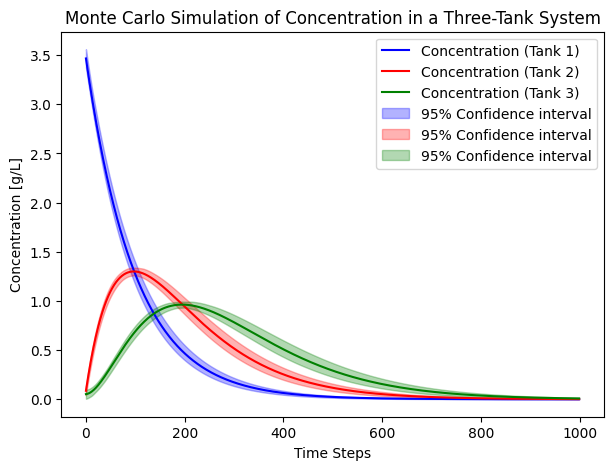

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(time_steps, c_mean_3_tanks[0], color = 'blue', label = 'Concentration (Tank 1)')
plt.plot(time_steps, c_mean_3_tanks[1], color = 'red', label = 'Concentration (Tank 2)')
plt.plot(time_steps, c_mean_3_tanks[2], color = 'green', label = 'Concentration (Tank 3)')
plt.fill_between(time_steps, ci_lower_3_tanks[0], ci_upper_3_tanks[0], alpha = 0.3, color = 'blue', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower_3_tanks[1], ci_upper_3_tanks[1], alpha = 0.3, color = 'red', label = "95% Confidence interval")
plt.fill_between(time_steps, ci_lower_3_tanks[2], ci_upper_3_tanks[2], alpha = 0.3, color = 'green', label = "95% Confidence interval")
plt.legend()
plt.ylabel('Concentration [g/L]')
plt.xlabel('Time Steps')
plt.title('Monte Carlo Simulation of Concentration in a Three-Tank System')
plt.show()

As seen in the plot above, tank $1$ decays rapidly, while Tanks $2$ and $3$ show delayed and lower peaks as the solute flows through the system. The confidence intervals indicate how uncertainty is transferred downstream.

## Part 3: Validation Againts ODE Solutions

We have the following system of equations

\begin{align*}
    \frac{dC_1}{dt} =& \frac{Q_{in}}{V} C_{in} - \frac{Q_{out}}{V} C_1,\\
    \frac{dC_2}{dt} =& \frac{Q_{in}}{V} C_{1} - \frac{Q_{out}}{V} C_2,\\
    \frac{dC_3}{dt} =& \frac{Q_{in}}{V} C_{2} - \frac{Q_{out}}{V} C_3.
\end{align*}

with the given average values

$$V = 1000 \text{ L} \quad Q_{out} = Q_{in} =  100 \text{ L/s} \quad C_{in} = 0.25 \text{ g/L} \quad C_1(0) = 3.5 \text{ g/L} \quad C_2(0) = C_3(0) = 0 \text{ g/L}$$

$$\textcolor{red}{\text{Write about how ODE solver works}}$$

$$\textcolor{red}{\text{Write about making ODE match MC}}$$

In [11]:
from ode_solver import ODESolver

def diff_eqns(c, t):
    ''' 3-tank system '''
    v = 1000
    q_in = q_out = 100
    c_in = 0.25

    c_1, c_2, c_3 = c
    dc = np.zeros(len(c))

    dc[0] = q_in/v * c_in - q_out/v * c_1 #Tank 1
    dc[1] = q_in/v * c_1 - q_out/v * c_2 #Tank 2
    dc[2] = q_in/v * c_2 - q_out/v * c_3 #Tank 3

    return dc

obj = ODESolver(diff_eqns, 0, 100, 0.1, [3.5, 0, 0], 'rk4', adaptive = False)
t_num, c_num = obj.solve()

#Convert physical time to match MC timesteps
t_num = t_num * 10
t_num = t_num[:len(time_steps)]
c_num = c_num[:len(time_steps)]


$$\textcolor{red}{\text{Write something about chaning Cin}\\\text{Change var names}}$$

In [ ]:
(c_mean_3_tanks,
 c_std_3_tanks,
 ci_lower_3_tanks,
 ci_upper_3_tanks
) = monte_carlo_simulation(t_start, t_final, n_particles, n_steps, n_tanks = 3, c_in = 0.25)

### Task 1 

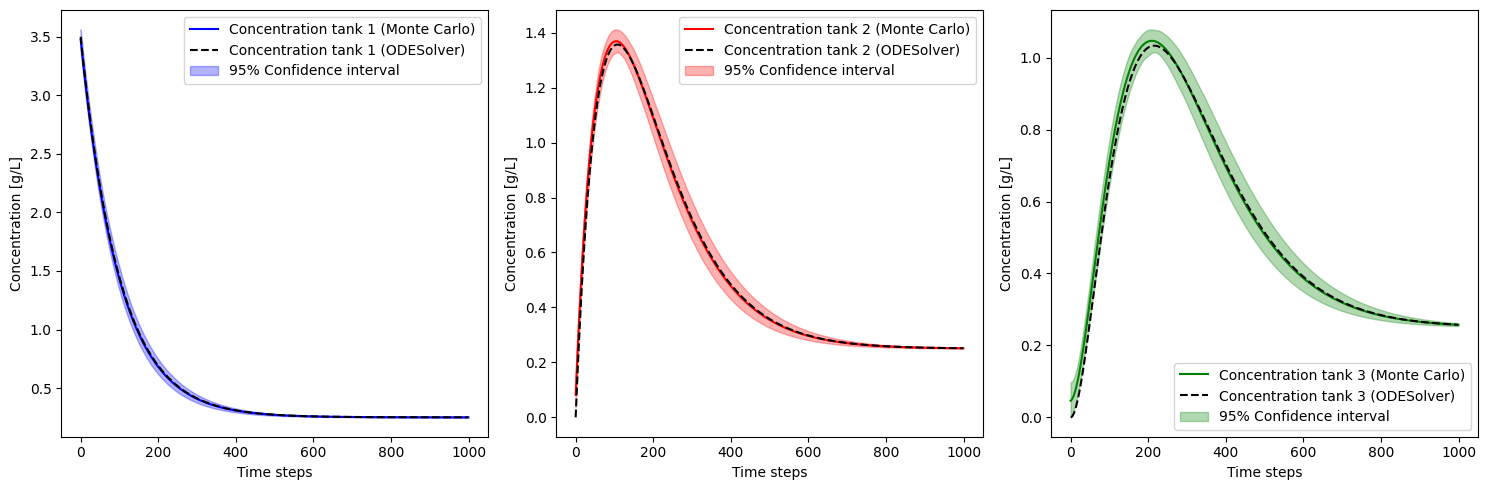

In [ ]:
plt.figure(figsize=(15, 5))
colors = ['blue', 'red', 'green']

for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(time_steps, c_mean_3_tanks[i], color = colors[i], label = f'Concentration tank {i + 1} (Monte Carlo)')
    plt.plot(t_num, c_num[:, i],'--', color = 'black', label = f'Concentration tank {i + 1} (ODESolver)')
    plt.fill_between(time_steps, ci_lower_3_tanks[i], ci_upper_3_tanks[i], alpha = 0.3, color = colors[i], label = "95% Confidence interval")
    plt.legend()
    plt.ylabel('Concentration [g/L]')
    plt.xlabel('Time steps')

plt.tight_layout()
plt.show()

### Task 2

$$\textcolor{red}{\text{Evaluate accuracy, consistency, and computational efficiency of the stochastic approach}\\\text{maybe find a way to show this numbers, the root-mean-square difference between the MC mean and ODE}}$$

### Task 3

$$\textcolor{red}{\text{Discuss advantages and limitations of Monte Carlo methods versus deterministic ODE solutions.}\\\text{(e.g. “the maximum absolute difference between the MC mean and ODE solution over time is about X g”) or compare CPU time (“the MC simulation took about XX s for 100 runs, whereas the ODE solver took YY s”).}}$$

# Exercise 2: Spreading of contaminants in underground aquifers using random walk

## Part 1: 2D Random Walk Model

### Task 1 - Something

In [14]:
import random
rnd.seed(18)
random.seed(18)

def random_walk_2d_basic(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north, south, east, west, stay]

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

In [15]:
n_steps = 1000
n_particles = 1000

side = int(np.sqrt(n_particles))  # 31 x 31 ≈ 1000
offset = side // 2

start_pos = [(1000 + i - offset, 1000 + j - offset)
             for i in range(side)
             for j in range(side)]

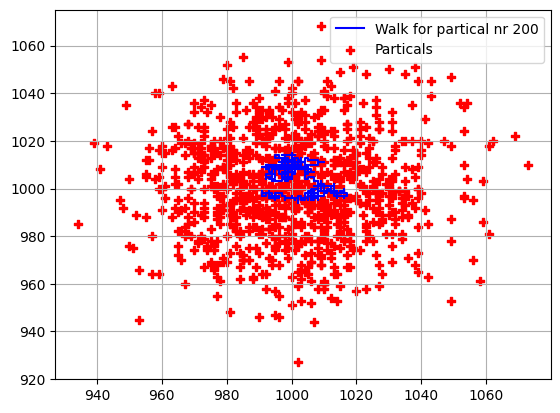

In [16]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_basic(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

In [17]:
def random_walk_2d_weighted(n_steps, start_pos = (1000, 1000), bounds = (0, 2000)):

    #Start position
    x, y = start_pos
    x_path = [x]
    y_path = [y]

    #Directions to choose from (dx, dy)
    north = (0, 1)
    north_west = (-1, 1)
    north_east = (1, 1)
    south = (0, -1)
    south_west = (-1, -1)
    south_east = (1, -1)
    east = (1, 0)
    west = (-1, 0)
    stay = (0, 0)

    directions = [north,
                  north_west,
                  north_east,
                  south,
                  south_west,
                  south_east,
                  east,
                  west,
                  stay]

    probabilities = np.array([0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.1,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    for _ in range(n_steps):

        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Boundary check
        if not (bounds[0] <= x <= bounds[1] and bounds[0] <= y <= bounds[1]):
            break

        x_path.append(x)
        y_path.append(y)

    return x_path, y_path

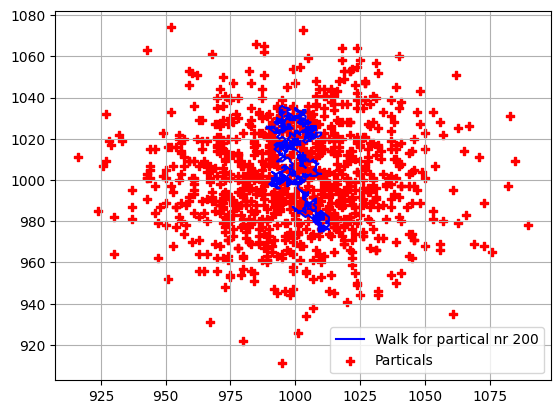

In [18]:
points = []
paths = []

n_steps = 1000
n_particles = 1000

for pos in start_pos:
    x_path, y_path = random_walk_2d_weighted(n_steps, pos)
    paths.append((x_path, y_path))
    points.append((x_path[-1], y_path[-1]))

x_coords, y_coords = zip(*points)

#Path of partical 200
x_200, y_200 = paths[200]

#Plotting
plt.plot(x_200, y_200, '-', color = 'blue', label = 'Walk for partical nr 200')
plt.scatter(x_coords, y_coords, marker = 'P', color = 'red', label = 'Particals')
plt.legend()
plt.grid()
plt.show()

## Part 2: 2D Random Walk Model of Contaminant Transport in Aquifers

### Task 1

In [19]:
source = (1000, 1000)

### Task 2

In [20]:
distance_m = 10_000 #meters
migration_rate = 10 #meters/year

minimum_time = distance_m / migration_rate #years

print(f'The minimum time required for the contaminant to reach 10 km is {minimum_time} years')

The minimum time required for the contaminant to reach 10 km is 1000.0 years


### Task 3

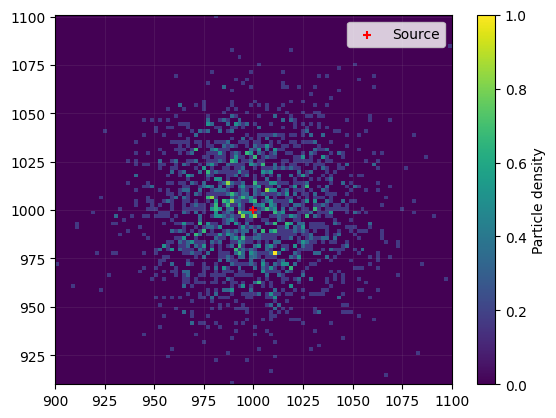

In [21]:
n_particles = 2000
n_steps = 2000

final_pos = []

for i in range(n_particles):
    x_path, y_path = random_walk_2d_basic(n_steps, source)
    final_pos.append((x_path[-1], y_path[-1]))

final_pos_x, final_pos_y = zip(*final_pos)

#Plotting
plt.hist2d(final_pos_x, final_pos_y, bins=100)
plt.scatter(1000, 1000, color='red', marker='+', label='Source')
plt.colorbar(label="Particle density")
plt.legend()
plt.grid(alpha = 0.1)
plt.show()

### Task 4

In [22]:
random.seed(67)
def time_to_reach_distance_unbiased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #To improve computational speed
    distance_to_reach = distance_to_reach**2

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    while True:
        #Choose a dicection at randon
        dx, dy = random.choice(directions)

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        distance =(x - start_pos[0])**2 + (y - start_pos[1])**2
        if distance >= distance_to_reach:
            return years


In [23]:
arrival_times_unbiased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_unbiased.append(time_to_reach_distance_unbiased(1000, (1000, 1000)))

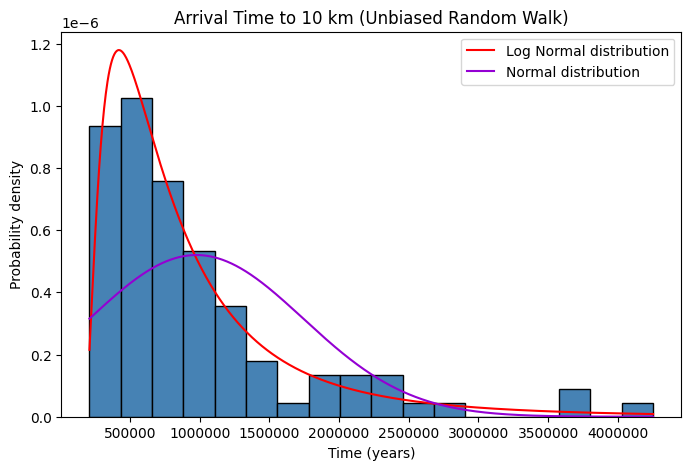

In [24]:
import scipy.stats as stats
arrival_times_unbiased = np.array(arrival_times_unbiased)
shape, loc, scale = stats.lognorm.fit(arrival_times_unbiased)
mu, sigma = arrival_times_unbiased.mean(), arrival_times_unbiased.std()
x = np.linspace(min(arrival_times_unbiased), max(arrival_times_unbiased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_unbiased, bins=18,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Unbiased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()


### Task 5

In [25]:
random.seed(18)
def time_to_reach_distance_biased(distance_to_reach = 1000, start_pos = (1000, 1000)):
    years = 0

    #Start position
    x, y = start_pos

    #Directions to choose from (dx, dy)
    north = (0, 1)
    south = (0, -1)
    east = (1, 0)
    west = (-1, 0)

    directions = [north, south, east, west]

    probabilities = np.array([0.2,
                              0.4,
                              0.2,
                              0.2])

    #Make sure sum of prob is 1
    assert np.isclose(probabilities.sum(),1), 'Probabilities must sum to 1'

    while True:
        #Choose a dicection at randon
        dx, dy = random.choices(directions, weights = probabilities)[0]

        #Walk
        x += dx
        y += dy

        #Steps
        years += 1

        #See if distance is reached
        target_y = start_pos[1] - distance_to_reach
        if y <= target_y:
            return years


In [26]:
arrival_times_biased = []

n_runs = 100

for i in range(n_runs):
    arrival_times_biased.append(time_to_reach_distance_biased(1000, (1000, 1000)))

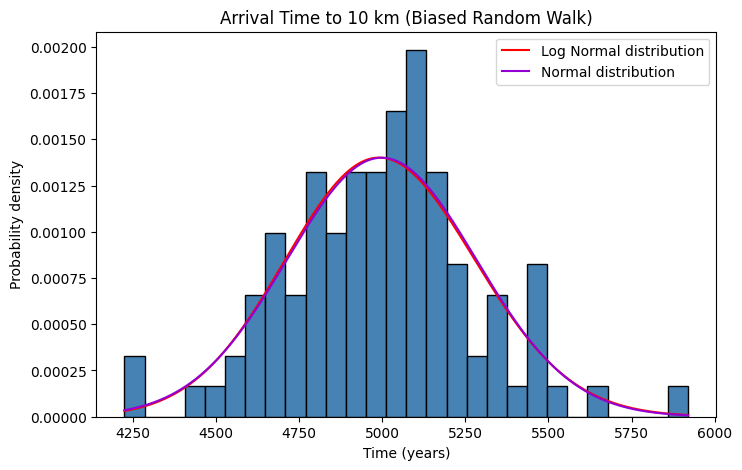

In [27]:
arrival_times_biased = np.array(arrival_times_biased)
shape, loc, scale = stats.lognorm.fit(arrival_times_biased)
mu, sigma = arrival_times_biased.mean(), arrival_times_biased.std()
x = np.linspace(min(arrival_times_biased), max(arrival_times_biased), 1000)

plt.figure(figsize=(8, 5))
plt.hist(arrival_times_biased, bins=28,density=True, edgecolor='black', color = 'steelblue')
plt.title('Arrival Time to 10 km (Biased Random Walk)')
plt.plot(x, stats.lognorm.pdf(x, shape, loc, scale), color = 'red', label = 'Log Normal distribution')
plt.plot(x, stats.norm.pdf(x, mu, sigma), color = 'darkviolet', label = 'Normal distribution')
plt.xlabel('Time (years)')
plt.ylabel('Probability density')
plt.legend()
plt.ticklabel_format(style='plain', axis='x')
plt.show()

# Bibliography
<a id="bib"></a>

\[$1$\] A. Gezerlis, *Numerical Methods in Physics with Python*, 2nd ed. Cambridge, UK: Cambridge University Press, 2023.